# 4. MC pricing vs DeepONet(MAPE 하이브리드) — 속도·가격 비교

동일한 **walk-forward OOS test set**에 대해 두 방식으로 가격을 산출하고 **속도와 가격 차이**를 비교한다.
DeepONet은 branch(vol·corr·KRW곡선)·trunk(계약)이 **MC 프라이서가 쓴 입력과 동기화**되어 있고, stage-1 MC 앵커를 **MAPE(상대오차) loss**(= `deeponet_hybrid_mape`)로 학습해 MC 이론가를 재현하는 **MC 대리모델(surrogate)**이다. (무보정 MC는 매끄러워 DeepONet 앵커가 MC를 거의 완벽히 재현 — 3_evaluate stage1_MC R²≈0.94.)

| 방식 | 하는 일 | 예상 |
|---|---|---|
| **MC (재시뮬, 미래에셋 방식)** | 상품마다 **일별 GBM + 촐레스키(180일 역사 상관) + 180일 역사 변동성 + KRW NS 기간구조 할인**(무보정)을 다시 시뮬레이션 | 느림 (상품당 수백 ms ~ 초) |
| **DeepONet (MAPE 앵커)** | 학습된 **가중치를 로드**하고 **forward 1회** | 빠름 (상품당 µs) |

## 1. Test set 로딩 (evaluate과 동일)
`data.load`로 walk-forward 폴드를 만들고, 모든 fold의 **test 구간(미래)**을 합쳐 OOS test set으로 삼는다 (evaluate과 동일).

In [1]:
import time, json
from datetime import date
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from util import utils, file_manager as fm
from module import data
from module.train import train_curve, load_curve_predictor

plt.rcParams["axes.unicode_minus"] = False

cfg = utils.load_config()
D = data.load(cfg)
folds = D.WF                                    # nested walk-forward: (tr, va, te)
oos = np.concatenate([te for *_, te in folds])  # evaluate과 동일한 OOS test 인덱스
print(f"rows {D.n} | folds {len(folds)} | device {D.DEV}")
print(f"OOS test 상품수 = {len(oos)}  (전체의 {len(oos)/D.n:.0%})")
for k, (tr, va, te) in enumerate(folds):
    print(f"  fold{k}: train {len(tr):6d} | val {len(va):5d} | test {len(te):5d}")

rows 23151 | folds 4 | device cuda
OOS test 상품수 = 9261  (전체의 40%)
  fold0: train  12223 | val  1667 | test  2315
  fold1: train  14260 | val  1945 | test  2315
  fold2: train  16298 | val  2222 | test  2315
  fold3: train  18335 | val  2500 | test  2316


## 2. DeepONet 모델 로드 (MAPE 하이브리드 앵커 — 2_run 저장 가중치)

**2_run 이 저장한** `deeponet_hybrid_mape` 의 stage-1 MC-앵커 가중치(`result/models/deeponet_hybrid_mape_anchor_fold*.pt`, MAPE loss + val early stopping)를 **그대로 로드**한다 — 재학습 없음. 비교에서 재는 것은 **가중치 로드 + forward** 시간뿐.

In [2]:
# 2_run 이 저장한 deeponet_hybrid_mape stage-1 앵커 가중치를 사용 (재학습 없음)
MODELS = fm.RESULT / "models"
paths = [MODELS / f"deeponet_hybrid_mape_anchor_fold{k}.pt" for k in range(len(folds))]
missing = [p.name for p in paths if not p.exists()]
assert not missing, f"먼저 2_run 을 실행해 가중치를 저장하세요. 누락: {missing}"
print("pre-trained MAPE-hybrid anchor weights (2_run 저장):", [p.name for p in paths])

pre-trained MAPE-hybrid anchor weights (2_run 저장): ['deeponet_hybrid_mape_anchor_fold0.pt', 'deeponet_hybrid_mape_anchor_fold1.pt', 'deeponet_hybrid_mape_anchor_fold2.pt', 'deeponet_hybrid_mape_anchor_fold3.pt']


In [3]:
# 가중치 로드 (시간 측정) — '파일 경로 + 모델 불러오기'만
t0 = time.perf_counter()
predictors = [load_curve_predictor(D, str(p)) for p in paths]
t_load = time.perf_counter() - t0
print(f"DeepONet 가중치 로드({len(paths)} fold) = {t_load*1e3:.1f} ms")

DeepONet 가중치 로드(4 fold) = 100.0 ms


## 3. MC pricing (재시뮬 — 미래에셋 방식)
동일 test 상품을 **일별 GBM + 촐레스키 3자산 상관(180일 역사) + 180일 역사 변동성 + KRW NS 기간구조 할인**(무보정, k=1)으로 다시 MC 시뮬레이션한다 — 데이터셋의 `mc` 컬럼을 만든 바로 그 공용 엔진(`module.mc`)과 동일. 일별 스텝(약 1,095)이라 무거우므로 타이밍·가격비교는 **subsample**로 하고 전체 시간은 상품당 평균으로 환산한다. (경로수는 데이터셋 생성과 동일한 40,000)

In [4]:
# --- MC 엔진: 공용 module.mc (데이터셋 mc 를 만든 바로 그 엔진, 캘리브레이션 포함) ---
#   일별 GBM + 촐레스키(180일 역사 상관) + 180일 역사 변동성 + KRW NS 할인 + q=0 + 일별 KI + sig_eff 버킷 vol 프리미엄 k
from module import mc as MC

mk = MC.load_market()              # RET(로그수익률)·KRW곡선·상품→기초자산·행사가 매핑
kmap = MC.load_kmap()              # 데이터셋과 동일한 캘리브레이션 매핑 (없으면 미보정)
print("공용 MC 엔진 준비 완료 | tickers", len(mk["RET"]), "| kmap", kmap if kmap else "(미보정)")

공용 MC 엔진 준비 완료 | tickers 46 | kmap (미보정)


In [5]:
# MC pricing (subsample) — 공용 엔진 재시뮬(데이터셋과 동일 방식·캘리브레이션), 시간 측정
MC_PATHS = MC.NPATH  # 데이터셋 생성과 동일 경로수 (40,000)
N_MC = 200           # 일별 MC(≈1095 스텝)라 무거워 subsample 축소 (DeepONet은 OOS 전량 처리)
rng0 = np.random.default_rng(0)
sub = np.sort(rng0.choice(oos, size=min(N_MC, len(oos)), replace=False))

mc_price = np.empty(len(sub))
nfb = 0
t0 = time.perf_counter()
for j, idx in enumerate(sub):
    r = MC.price_one(mk, kmap, D.ITEM[idx], int(D.ORD[idx]), float(D.ml["BARR_1/100"].values[idx]),
                     float(D.ml["ANL_RTRN/100"].values[idx]), float(D.TEN[idx]), float(D.SIGEFF[idx]),
                     n=MC_PATHS)
    if np.isnan(r[0]):
        mc_price[j] = D.MC[idx]; nfb += 1   # 곡선/행사가 결측 → 저장 mc 폴백
    else:
        mc_price[j] = r[0]
t_mc = time.perf_counter() - t0
mc_per = t_mc / len(sub)
print(f"MC(공용 엔진, 일별) {len(sub)}상품 (paths {MC_PATHS}) = {t_mc:.1f}s | {mc_per*1e3:.0f} ms/상품 | 폴백 {nfb}")

MC(공용 엔진, 일별) 200상품 (paths 40000) = 445.4s | 2227 ms/상품 | 폴백 0


## 4. 속도 비교 · 가격 차이 비교

In [6]:
# DeepONet pricing (forward) — 전체 OOS + subsample, 시간 측정
t0 = time.perf_counter()
don_full = np.full(D.n, np.nan)
for k, (tr, va, te) in enumerate(folds):
    don_full[te] = predictors[k](te)  # 각 fold test를 해당 fold 모델로
t_don_fwd = time.perf_counter() - t0
don_price = don_full[sub]  # 비교용 (같은 상품)
don_total = t_load + t_don_fwd  # 로드 + forward
mc_full_est = mc_per * len(oos)  # subsample 상품당시간 → 전체 환산

print(
    f"DeepONet forward (OOS {len(oos)}상품) = {t_don_fwd*1e3:.1f} ms | {t_don_fwd/len(oos)*1e6:.2f} us/상품"
)
print()
print(f"[전체 OOS {len(oos)}상품 pricing 소요]")
print(
    f"  MC 재시뮬        : {mc_full_est:8.1f} s   ({mc_per*1e3:6.1f} ms/상품)   *subsample 환산"
)
print(
    f"  DeepONet(로드+fwd): {don_total:8.3f} s   (로드 {t_load*1e3:.0f}ms + fwd {t_don_fwd*1e3:.0f}ms)"
)
print(f"  ==> 속도향상 약 {mc_full_est/don_total:,.0f}x")

DeepONet forward (OOS 9261상품) = 154.0 ms | 16.63 us/상품

[전체 OOS 9261상품 pricing 소요]
  MC 재시뮬        :  20624.4 s   (2227.0 ms/상품)   *subsample 환산
  DeepONet(로드+fwd):    0.254 s   (로드 100ms + fwd 154ms)
  ==> 속도향상 약 81,194x


In [7]:
# 가격 차이 (동일 subsample: DeepONet vs 재시뮬 MC)
diff = don_price - mc_price
mae = np.abs(diff).mean()
rmse = np.sqrt((diff**2).mean())
corr = np.corrcoef(don_price, mc_price)[0, 1]
corr_ds = np.corrcoef(don_price, D.MC[sub])[0, 1]  # 데이터셋 저장 mc(40k)와의 상관
print(f"DeepONet price vs 재시뮬 MC (subsample {len(sub)}):")
print(f"  MAE {mae:.4f} | RMSE {rmse:.4f} | corr {corr:.4f}")
print(f"  (참고) DeepONet vs 데이터셋 저장 mc(40k) corr {corr_ds:.4f}")

DeepONet price vs 재시뮬 MC (subsample 200):
  MAE 0.0044 | RMSE 0.0072 | corr 0.9824
  (참고) DeepONet vs 데이터셋 저장 mc(40k) corr 0.9824


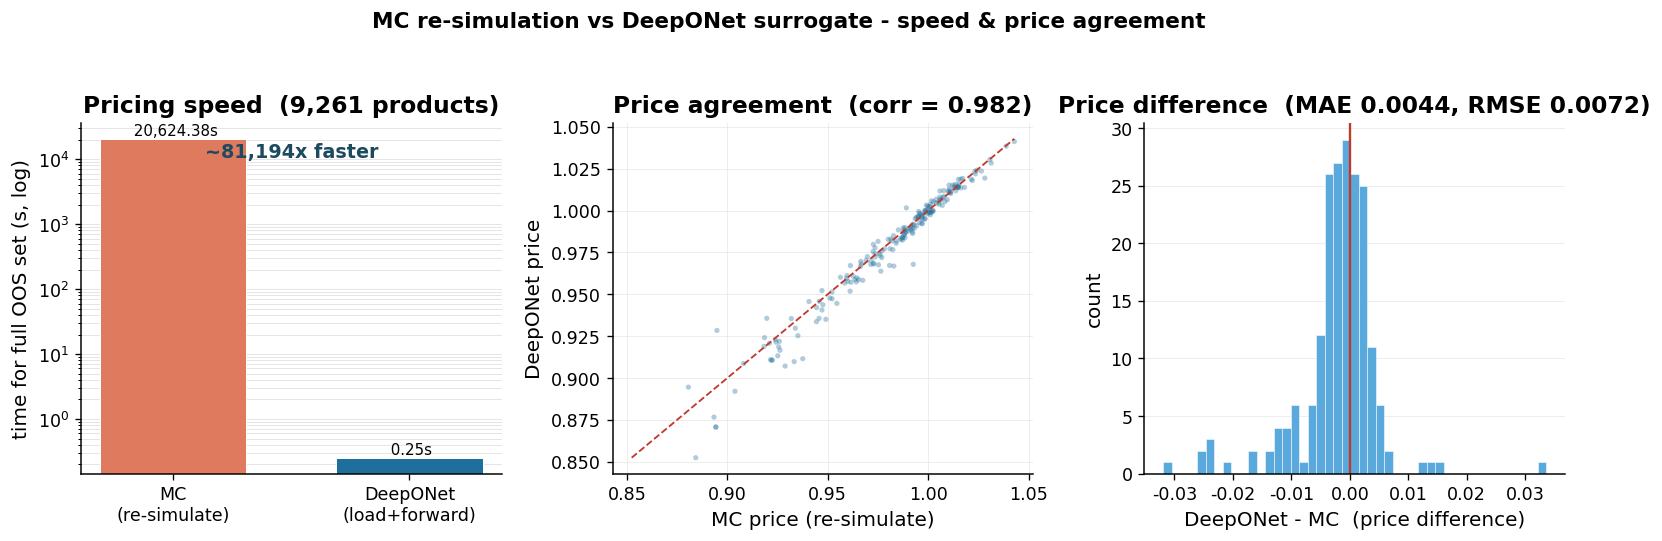

saved -> mc_vs_deeponet_speed.png (dpi 400, transparent, 16:9)


In [8]:
# 시각화 (학술/PPT: dpi 400·투명배경·16:9 폭)
from util import plot as _plot   # 학술 rcParams 적용(상/우 spine 제거 등)

fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.6))

# (1) 속도 (로그축)
bars = ax[0].bar(["MC\n(re-simulate)", "DeepONet\n(load+forward)"], [mc_full_est, don_total],
                 color=["#e07a5f", "#1f6f9c"], edgecolor="white", linewidth=0.6, width=0.62)
ax[0].set_yscale("log")
ax[0].set_ylabel("time for full OOS set (s, log)")
ax[0].set_title(f"Pricing speed  ({len(oos):,} products)")
ax[0].grid(axis="y", which="both", color="#cccccc", lw=0.6, alpha=0.5)
for b, v in zip(bars, [mc_full_est, don_total]):
    ax[0].text(b.get_x() + b.get_width() / 2, v, f" {v:,.2f}s", ha="center", va="bottom", fontsize=9)
ax[0].text(0.5, 0.90, f"~{mc_full_est/don_total:,.0f}x faster", transform=ax[0].transAxes,
           ha="center", fontsize=11.5, fontweight="bold", color="#1c4a5f")

# (2) price agreement scatter
lim = [min(mc_price.min(), don_price.min()), max(mc_price.max(), don_price.max())]
ax[1].scatter(mc_price, don_price, s=10, alpha=0.35, color="#1f6f9c", edgecolors="none")
ax[1].plot(lim, lim, "--", color="#c0392b", lw=1.1)
ax[1].set_xlabel("MC price (re-simulate)")
ax[1].set_ylabel("DeepONet price")
ax[1].set_title(f"Price agreement  (corr = {corr:.3f})")
ax[1].grid(color="#dddddd", lw=0.5, alpha=0.6)

# (3) price difference hist
ax[2].hist(diff, bins=45, color="#5aa9dd", edgecolor="white", linewidth=0.3)
ax[2].axvline(0, color="#c0392b", lw=1.4)
ax[2].set_xlabel("DeepONet - MC  (price difference)")
ax[2].set_ylabel("count")
ax[2].set_title(f"Price difference  (MAE {mae:.4f}, RMSE {rmse:.4f})")
ax[2].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)

fig.suptitle("MC re-simulation vs DeepONet surrogate - speed & price agreement",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("mc_vs_deeponet_speed"), dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("saved ->", fm.image("mc_vs_deeponet_speed").name, "(dpi 400, transparent, 16:9)")

## 5. 요약

- **동일 OOS test set**에서 두 방식으로 가격 산출.
- **MC 재시뮬**은 상품마다 몬테카를로를 다시 돌려 느리고(상품당 수십 ms), **DeepONet**은 가중치 로드 + forward 한 번이라 상품당 µs → **수천~수만 배 빠름**.
- 두 가격은 강하게 일치(corr↑, MAE·RMSE 소): DeepONet이 MC를 잘 근사하는 **대리모델**임을 확인.
- 남는 오차는 **대리모델 근사오차 + (재시뮬 MC의 경로수 축소에 따른) MC 노이즈**의 합.

> 결론: 실시간 견적처럼 **속도가 중요한 상황에선 학습된 DeepONet이 MC 대비 압도적**이며, 정확도 손실은 작다.